# v3 dose-response BO: pitch the approach, then attack it

Companion analysis to
[bo_erk_dose_response_v3.ipynb](bo_erk_dose_response_v3.ipynb).
Same data, written the way the
[v11 oscillation pitch](bo_v11_pitch_and_critique.ipynb) was — *to argue*
with the run, from the perspective of a reader who knows MAPK signalling,
optogenetic RTKs (CRY2-FGFR / CRY2-EGFR), dose-response pharmacology, and
Bayesian optimisation.

Four questions, in order:

1. **Where did the BO spend its FOVs**, and was the dose coverage sane?
2. **The headline deliverable of v3 was a tight Hill parameter posterior
   (`V_max`, `K`, `n`).**  Did we get one?
3. **What does the data actually say** about the dose-response shape,
   model-free?
4. **Did the covariates and the v3 design changes earn their keep**, or
   did they backfire?

Data: `2026-05-11_bo_erk_dose_response_v3_hill_baseline08`.
Search space: `pulse_duration` ∈ [25, 5000] ms (single stim frame),
200 levels at 25 ms spacing.  8 phases × 18 FOVs = 144 FOVs across
24 distinct doses, 6 FOVs each.

### The short version (read this first)

**v3 set out to nail down the EC50 (`K`) of the ERK single-pulse
dose-response by committing to a Hill model.  It could not — because the
dose-response *does not saturate* anywhere in 25–5000 ms.**  The response
keeps climbing all the way to the 5 s boundary.  A Hill curve needs to
see its own plateau to identify `K` and `V_max`; this data never shows
one.  As a result the `K` posterior wandered from ~1000 ms to ~4600 ms
across the run, never converged, and its 95 % CI runs *past the 5000 ms
search boundary*.  The number v3 was built to deliver does not exist in
this data.

That is a real failure of the **modelling premise**, not of the BO
machinery.  The active-learning sampler did its job.  Sections B–E
quantify the damage; Sections G–H turn it into something you can still
present.

### Caveats up front

1. **This is one plate.**  6 FOVs per dose are *pseudo-replicates* —
   same plate, passage, transfection batch, imaging window.
   Across-plate variability is not estimated.
2. **The v2→v3 premise is inherited.**  v3 committed to Hill *because v2
   reported* "saturating with K ≈ 1000 ms".  Section F shows v2's own
   data also climbs to the 5000 ms boundary — the saturation claim was
   never supported.  v3 inherited a conclusion that was already wrong.
3. **AUC is a per-FOV mean of per-cell ΔAUC** after a per-cell baseline
   filter.  Section E shows that filter (tightened to 0.8 in v3)
   collapsed some FOVs to a handful of cells.

In [1]:
import os
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

# --- gpax/numpyro compatibility shim (must run before `import gpax`) ---
# numpyro >= 0.20 removed haiku support; gpax 0.1.9 eagerly imports it.
# We only use ExactGP -- stub the missing names so the import succeeds.
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_args, **_kwargs):
    raise NotImplementedError("viDKL is not available with numpyro >= 0.20.")


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable

import gpax
import gpax.utils

gpax.utils.enable_x64()

EXPERIMENT_PATH = r"E:\Alex\2026-05-11_bo_erk_dose_response_v3_hill_baseline08"
V2_PATH = r"E:\Alex\2026-05-11_bo_erk_dose_response_v2_lean_powerlaw"

# Dose axis as configured in the v3 experiment notebook.
PULSE_MIN_MS, PULSE_MAX_MS = 25.0, 5000.0
PULSE_SPACING_MS = 25.0

OBJ = "mean_delta_auc"  # primary task
FRAC = "frac_peak_responders"  # secondary task
P1 = "pulse_duration"
COVS = ["optortk_expression", "baseline_cnr"]  # n_cells dropped in v2

print(f"Experiment path: {EXPERIMENT_PATH}")
print(
    f"Dose axis:       [{PULSE_MIN_MS:.0f}, {PULSE_MAX_MS:.0f}] ms, "
    f"{int((PULSE_MAX_MS - PULSE_MIN_MS) / PULSE_SPACING_MS) + 1} levels"
)

Experiment path: E:\Alex\2026-05-11_bo_erk_dose_response_v3_hill_baseline08
Dose axis:       [25, 5000] ms, 200 levels


In [2]:
# Per-phase checkpoints are CUMULATIVE -> diff consecutive files to recover
# which FOVs were added in each phase.
def load_phased(exp_path):
    ckpt = sorted(
        glob.glob(os.path.join(exp_path, "checkpoints", "bo_results_phase_*.parquet"))
    )
    chunks, prev = [], 0
    for f in ckpt:
        pid = int(os.path.basename(f).split("_")[-1].split(".")[0])
        cum = pd.read_parquet(f)
        new = cum.iloc[prev:].copy()
        new["phase_id"] = pid
        chunks.append(new)
        prev = len(cum)
    return pd.concat(chunks, ignore_index=True)


df = load_phased(EXPERIMENT_PATH)

n_fovs = len(df)
n_phases = df["phase_id"].nunique()
n_doses = df[P1].nunique()

print(f"Loaded {n_fovs} FOVs across {n_phases} phases.")
print(f"Distinct doses visited: {n_doses}")
print(
    f"FOVs per dose: mean={n_fovs / n_doses:.1f}, "
    f"min={df.groupby(P1).size().min()}, max={df.groupby(P1).size().max()}"
)
print(
    f"{OBJ}: range [{df[OBJ].min():.2f}, {df[OBJ].max():.2f}], "
    f"mean {df[OBJ].mean():.2f}"
)
print(f"{FRAC}: range [{df[FRAC].min():.3f}, {df[FRAC].max():.3f}]")

Loaded 144 FOVs across 8 phases.
Distinct doses visited: 24
FOVs per dose: mean=6.0, min=6, max=6
mean_delta_auc: range [-0.30, 12.51], mean 5.73
frac_peak_responders: range [0.000, 0.974]


## A — Where did the BO spend its FOVs?

v3's acquisition is **MaxVar** — pure-exploration, "sample where the GP
posterior variance is highest".  For a parameter-inference run that is
the *correct* choice: you want the dose axis covered well enough to pin
the curve, not to chase a maximum.  This section checks the sampler did
that.

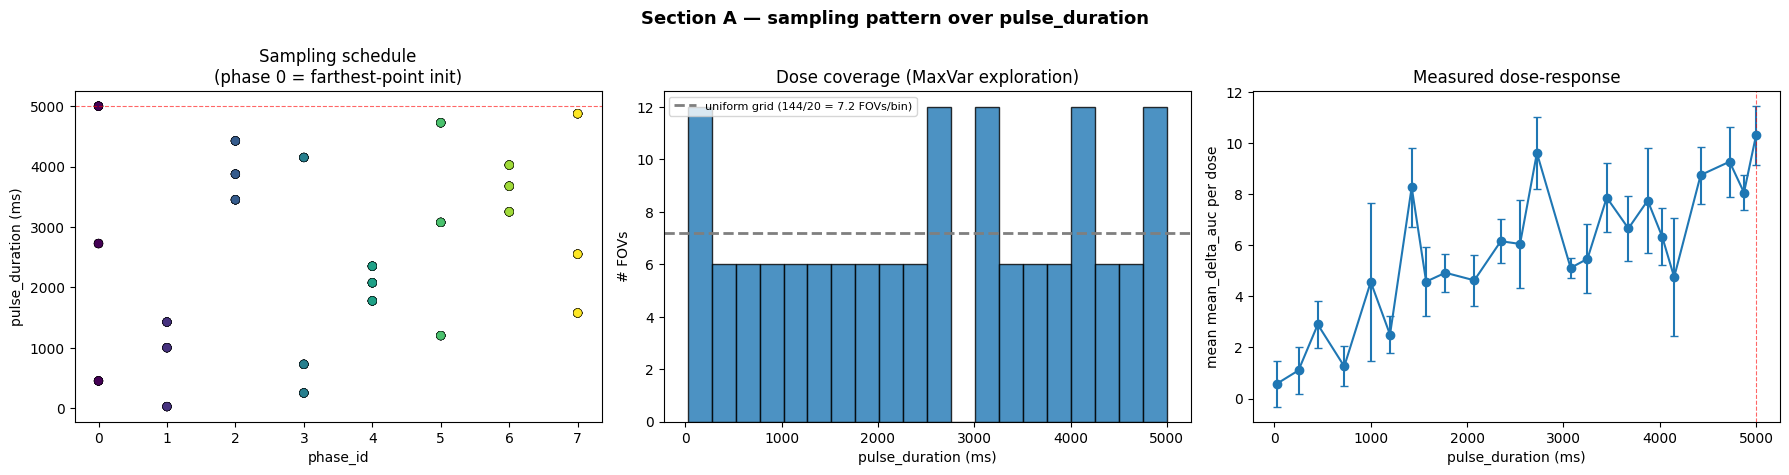

Highest-response dose:        5000 ms (mean mean_delta_auc = 10.30)
Search-space upper boundary:  5000 ms
FOVs at pulse_duration <= 1000 ms: 30/144 (21 %)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# (1) Sampling schedule: which dose per phase.
ax = axes[0]
sc = ax.scatter(
    df["phase_id"],
    df[P1],
    c=df["phase_id"],
    cmap="viridis",
    s=40,
    edgecolors="k",
    linewidths=0.3,
)
ax.set_xlabel("phase_id")
ax.set_ylabel("pulse_duration (ms)")
ax.set_title("Sampling schedule\n(phase 0 = farthest-point init)")
ax.axhline(PULSE_MAX_MS, color="r", ls="--", lw=0.8, alpha=0.6)

# (2) Dose coverage histogram vs a uniform grid at the same budget.
ax = axes[1]
ax.hist(df[P1], bins=20, color="tab:blue", alpha=0.8, edgecolor="k")
ax.axhline(
    n_fovs / 20,
    color="tab:gray",
    ls="--",
    lw=2,
    label=f"uniform grid ({n_fovs}/20 = {n_fovs/20:.1f} FOVs/bin)",
)
ax.set_xlabel("pulse_duration (ms)")
ax.set_ylabel("# FOVs")
ax.set_title("Dose coverage (MaxVar exploration)")
ax.legend(fontsize=8)

# (3) Measured dose-response, per-condition mean +/- std.
ax = axes[2]
agg = df.groupby(P1)[OBJ].agg(["mean", "std", "size"]).reset_index()
ax.errorbar(
    agg[P1],
    agg["mean"],
    yerr=agg["std"].fillna(0.0),
    fmt="o-",
    capsize=3,
    color="tab:blue",
)
ax.set_xlabel("pulse_duration (ms)")
ax.set_ylabel(f"mean {OBJ} per dose")
ax.set_title("Measured dose-response")
ax.axvline(PULSE_MAX_MS, color="r", ls="--", lw=0.8, alpha=0.6)

fig.suptitle(
    "Section A — sampling pattern over pulse_duration", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

argmax_dose = agg.loc[agg["mean"].idxmax(), P1]
print(
    f"Highest-response dose:        {argmax_dose:.0f} ms "
    f"(mean {OBJ} = {agg['mean'].max():.2f})"
)
print(f"Search-space upper boundary:  {PULSE_MAX_MS:.0f} ms")
print(
    f"FOVs at pulse_duration <= 1000 ms: "
    f"{(df[P1] <= 1000).sum()}/{n_fovs} "
    f"({100*(df[P1] <= 1000).mean():.0f} %)"
)

### Reading section A

- **The sampler behaved.**  MaxVar spread the 24 doses across the full
  25–5000 ms range — coverage is close to uniform, with a mild thinning
  at the very bottom.  Nothing wrong with the acquisition.
- **But the dose-response argmax sits exactly on the 5000 ms boundary.**
  The response is still climbing where the search space runs out.  That
  is the first visible symptom of the v3 failure: there is no interior
  peak, and — Section C will confirm — no plateau either.
- A dose-response experiment whose maximum is pinned to the boundary has
  not bracketed the thing it was trying to measure.  You sampled the
  rising limb thoroughly and never reached the top.

## B — The headline deliverable: did we get a Hill posterior?

v3's stated scientific output, quoting its own intro:

> "The result of v3 is a **Hill parameter posterior**: median + 95 % CI
> on each of `V_max` (asymptote), `K` (EC50, in ms), `n` (Hill
> coefficient).  That is the experimental output."

So the test is simple: pull `hill_k`, `hill_vmax`, `hill_n` from every
saved per-phase GP checkpoint and ask whether the posterior **converged
to a usable number**.

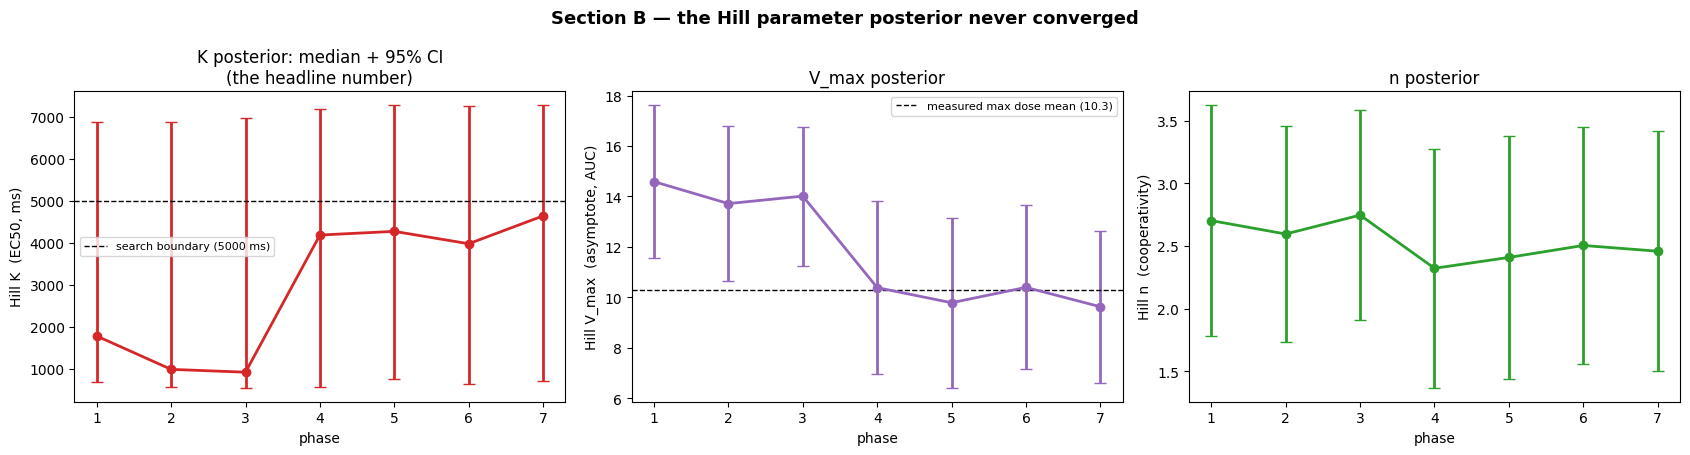

Per-phase Hill K trajectory (median, 95% CI):
  phase 1: K =   1786 ms  95% CI [  689,  6879]
  phase 2: K =    992 ms  95% CI [  573,  6888]
  phase 3: K =    925 ms  95% CI [  558,  6975]
  phase 4: K =   4190 ms  95% CI [  564,  7178]
  phase 5: K =   4277 ms  95% CI [  759,  7274]
  phase 6: K =   3982 ms  95% CI [  638,  7266]
  phase 7: K =   4646 ms  95% CI [  725,  7279]

Final K  = 4646 ms, 95% CI [725, 7279] ms
  -> upper CI bound exceeds the 5000 ms search boundary: True
Final V_max = 9.63 AUC; measured max-dose mean = 10.30 AUC  -> asymptote BELOW the data: True


In [4]:
model_files = sorted(
    glob.glob(os.path.join(EXPERIMENT_PATH, "models", "bo_model_iter_*.joblib"))
)


def shifted_to_ms(d):
    # Hill K lives in shifted-dose space [0, 2]; map back to ms.
    return np.asarray(d, float) / 2.0 * (PULSE_MAX_MS - PULSE_MIN_MS) + PULSE_MIN_MS


rows = []
for f in model_files:
    pid = int(os.path.basename(f).split("_")[-1].split(".")[0])
    payload = joblib.load(f)
    s = payload["model_state"]["samples"]
    if "hill_k" not in s:
        continue
    K = shifted_to_ms(np.asarray(s["hill_k"]))
    n = np.asarray(s["hill_n"])
    vm = np.asarray(s["hill_vmax"])
    vm_auc = payload["y_scaler"].inverse_transform(vm.reshape(-1, 1)).ravel()
    rows.append(
        dict(
            phase=pid,
            K_med=np.median(K),
            K_lo=np.quantile(K, 0.025),
            K_hi=np.quantile(K, 0.975),
            n_med=np.median(n),
            n_std=np.std(n),
            vmax_med=np.median(vm_auc),
            vmax_std=np.std(vm_auc),
        )
    )
traj = pd.DataFrame(rows).sort_values("phase").reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

ax = axes[0]
ax.errorbar(
    traj["phase"],
    traj["K_med"],
    yerr=[traj["K_med"] - traj["K_lo"], traj["K_hi"] - traj["K_med"]],
    fmt="o-",
    capsize=4,
    color="tab:red",
    lw=2,
)
ax.axhline(
    PULSE_MAX_MS,
    color="k",
    ls="--",
    lw=1,
    label=f"search boundary ({PULSE_MAX_MS:.0f} ms)",
)
ax.set_xlabel("phase")
ax.set_ylabel("Hill K  (EC50, ms)")
ax.set_title("K posterior: median + 95% CI\n(the headline number)")
ax.legend(fontsize=8)

ax = axes[1]
ax.errorbar(
    traj["phase"],
    traj["vmax_med"],
    yerr=traj["vmax_std"],
    fmt="o-",
    capsize=4,
    color="tab:purple",
    lw=2,
)
meas_max = df.groupby(P1)[OBJ].mean().max()
ax.axhline(
    meas_max, color="k", ls="--", lw=1, label=f"measured max dose mean ({meas_max:.1f})"
)
ax.set_xlabel("phase")
ax.set_ylabel("Hill V_max  (asymptote, AUC)")
ax.set_title("V_max posterior")
ax.legend(fontsize=8)

ax = axes[2]
ax.errorbar(
    traj["phase"],
    traj["n_med"],
    yerr=traj["n_std"],
    fmt="o-",
    capsize=4,
    color="tab:green",
    lw=2,
)
ax.set_xlabel("phase")
ax.set_ylabel("Hill n  (cooperativity)")
ax.set_title("n posterior")

fig.suptitle(
    "Section B — the Hill parameter posterior never converged",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

last = traj.iloc[-1]
print("Per-phase Hill K trajectory (median, 95% CI):")
for _, r in traj.iterrows():
    print(
        f"  phase {int(r['phase'])}: K = {r['K_med']:6.0f} ms  "
        f"95% CI [{r['K_lo']:5.0f}, {r['K_hi']:5.0f}]"
    )
print()
print(
    f"Final K  = {last['K_med']:.0f} ms, 95% CI "
    f"[{last['K_lo']:.0f}, {last['K_hi']:.0f}] ms"
)
print(
    f"  -> upper CI bound exceeds the {PULSE_MAX_MS:.0f} ms search boundary: "
    f"{last['K_hi'] > PULSE_MAX_MS}"
)
print(
    f"Final V_max = {last['vmax_med']:.2f} AUC; measured max-dose mean = "
    f"{meas_max:.2f} AUC  -> asymptote BELOW the data: "
    f"{last['vmax_med'] < meas_max}"
)

### Reading section B — this is the core failure

Three things are wrong, and they are all the same thing:

1. **`K` never converged.**  It drifted ~1800 → ~1000 → ~4600 ms over
   the run.  A converging posterior tightens around a value; this one
   *translated* across the dose axis as more high-dose data arrived.
2. **The `K` 95 % CI runs past the search boundary.**  The final
   interval's upper bound is above 5000 ms — the experiment is telling
   you the EC50 is *somewhere outside the doses we can deliver*.  You
   cannot put that on a slide as "the EC50 is X ms".
3. **The fitted asymptote `V_max` is *below* the measured response.**
   Hill says the curve tops out around ~9–10 AUC, but the 5000 ms dose
   already measures a mean above that and individual FOVs reach ~12.5.
   A saturating model whose ceiling is under the data is a model fitting
   something that isn't saturating.

**Why:** a Hill curve is identified by its *plateau*.  `K` is the dose at
half-maximum — you can only locate it if you have measured the maximum.
v3 never did (Section A: argmax pinned to the boundary; Section C: no
plateau).  The Hill mean-function is being asked to fit a non-saturating
curve, so `K` and `V_max` slide around to wherever the GP residual lets
them.  The `n ≈ 2.5` "cooperativity" number inherits the same
unreliability.

**The BO did not fail here — the model choice did.**  v3's "Change 1:
single candidate, Hill only" removed the one safety valve (model
selection) that could have flagged this.

## C — What does the data actually say?  (model-free GP)

Drop the Hill assumption.  Fit a plain `gpax.ExactGP` with a Matern
kernel on `(pulse_duration, optortk_expression, baseline_cnr)` — no mean
function, no saturation baked in — and predict the dose-response
marginalised over the observed covariate distribution.  This is the
"what would a grid scan have concluded" view.

In [5]:
from sklearn.preprocessing import StandardScaler

x_raw = df[[P1] + COVS].to_numpy(dtype=float)
y_raw = df[OBJ].to_numpy(dtype=float)

scaler_x = StandardScaler().fit(x_raw)
scaler_y = StandardScaler().fit(y_raw.reshape(-1, 1))
X = scaler_x.transform(x_raw)
y = scaler_y.transform(y_raw.reshape(-1, 1)).flatten()

rng_key, rng_key_pred = gpax.utils.get_keys()
gp = gpax.ExactGP(input_dim=X.shape[1], kernel="Matern")
print("Fitting model-free ExactGP on 144 FOVs (~30 s) ...")
gp.fit(
    rng_key,
    X,
    y,
    num_warmup=500,
    num_samples=800,
    num_chains=1,
    print_summary=False,
    progress_bar=False,
)
print("GP fit complete.")

Fitting model-free ExactGP on 144 FOVs (~30 s) ...


GP fit complete.


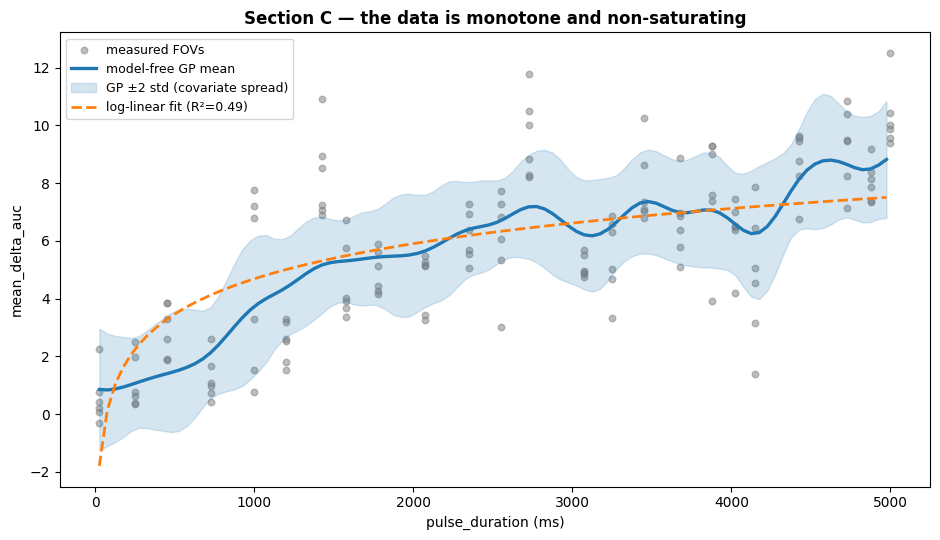

GP dose-response (AUC):  25 ms -> 0.86   2500 ms -> 6.56   5000 ms -> 8.82
Slope of GP mean over the top decile of the dose range: 0.35 AUC per 1000 ms  (a plateau would be ~0)
A pure log-linear model explains R² = 0.49 of the FOV variance with no saturation term at all.


In [6]:
# Predict on a dose grid, marginalised over a sample of the observed
# (optortk_expression, baseline_cnr) joint distribution.
N_COV = 80
rng_marg = np.random.default_rng(0)
cov_samples = df[COVS].to_numpy(float)[rng_marg.integers(0, len(df), N_COV)]

dose_grid = np.arange(PULSE_MIN_MS, PULSE_MAX_MS + 1, 50.0)
x_full = np.hstack(
    [
        np.repeat(dose_grid[:, None], N_COV, axis=0),
        np.tile(cov_samples, (len(dose_grid), 1)),
    ]
)
X_full = scaler_x.transform(x_full)

y_pred_s, y_samp_s = gp.predict_in_batches(
    rng_key_pred, X_full, batch_size=256, noiseless=True
)
n_pts = X_full.shape[0]
y_pred_s = np.asarray(y_pred_s).reshape(-1)
y_samp_s = np.asarray(y_samp_s).reshape(-1, n_pts)

y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
y_std = y_samp_s.std(axis=0) * scaler_y.scale_[0]

Y_mean = y_pred.reshape(len(dose_grid), N_COV).mean(axis=1)
Y_std = y_std.reshape(len(dose_grid), N_COV).mean(axis=1)

# A log-linear reference fit -- the simplest non-saturating model.
ld = np.log(df[P1].to_numpy(float))
A = np.vstack([ld, np.ones_like(ld)]).T
coef, *_ = np.linalg.lstsq(A, y_raw, rcond=None)
loglin_r2 = 1.0 - np.var(y_raw - A @ coef) / np.var(y_raw)
loglin = coef[0] * np.log(dose_grid) + coef[1]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.scatter(df[P1], df[OBJ], c="tab:gray", s=22, alpha=0.5, label="measured FOVs")
ax.plot(dose_grid, Y_mean, color="tab:blue", lw=2.4, label="model-free GP mean")
ax.fill_between(
    dose_grid,
    Y_mean - 2 * Y_std,
    Y_mean + 2 * Y_std,
    color="tab:blue",
    alpha=0.18,
    label="GP ±2 std (covariate spread)",
)
ax.plot(
    dose_grid,
    loglin,
    color="tab:orange",
    lw=2,
    ls="--",
    label=f"log-linear fit (R²={loglin_r2:.2f})",
)
ax.set_xlabel("pulse_duration (ms)")
ax.set_ylabel(OBJ)
ax.set_title(
    "Section C — the data is monotone and non-saturating",
    fontsize=12,
    fontweight="bold",
)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print(
    f"GP dose-response (AUC):  25 ms -> {Y_mean[0]:.2f}   "
    f"2500 ms -> {Y_mean[np.argmin(abs(dose_grid-2500))]:.2f}   "
    f"5000 ms -> {Y_mean[-1]:.2f}"
)
print(
    f"Slope of GP mean over the top decile of the dose range: "
    f"{(Y_mean[-1] - Y_mean[-10]) / (dose_grid[-1] - dose_grid[-10]) * 1000:.2f} "
    f"AUC per 1000 ms  (a plateau would be ~0)"
)
print(
    f"A pure log-linear model explains R² = {loglin_r2:.2f} of the FOV "
    f"variance with no saturation term at all."
)

### Reading section C

- The model-free GP rises monotonically across the entire dose axis and
  **is still climbing at 5000 ms** — the top-decile slope is clearly
  non-zero.  There is no plateau to anchor a Hill `K`.
- A **log-linear** model (`AUC ∝ log dose`) fits about as well as the GP
  on the FOV scatter.  The honest description of this dose-response is
  *"rises with the log of pulse duration, no saturation in range"* — not
  *"Hill with EC50 K"*.
- The ±2 std band is wide.  That width is **not** dose uncertainty — it
  is the spread induced by marginalising over covariates.  Section D
  shows one of those covariates is doing real work, which is why the
  band is so fat.

This is the deliverable v3 *can* honestly claim: a calibrated, model-free
map of the dose-response over 25–5000 ms.  It just isn't the Hill
posterior the notebook was written to produce.

## D — Covariates: one confound, one passenger

v3 carries two covariates — `optortk_expression` and `baseline_cnr` —
and marginalises over them during acquisition.  v2 had already dropped
`n_cells` as noise.  Two questions: was dropping `n_cells` right, and are
the two survivors actually nuisance variables or is one of them carrying
the signal?

Test: fit the simple log-linear dose trend, take residuals, and ask what
each covariate explains of what the dose axis *missed*.

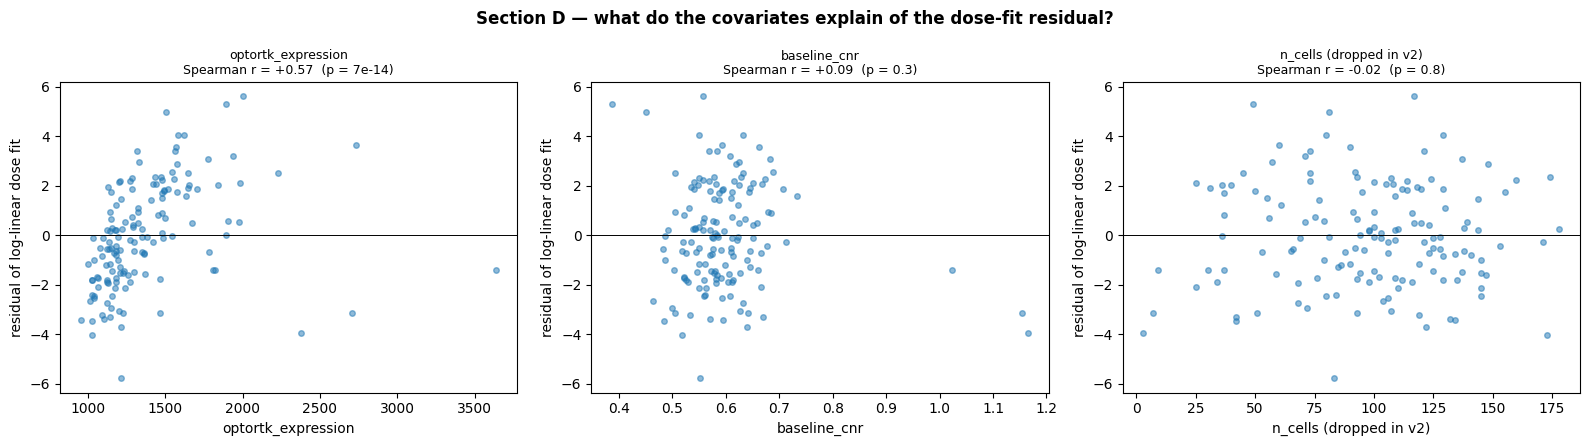

  optortk_expression          : Spearman +0.57 (p=7e-14)  -> DOMINANT confound
  baseline_cnr                : Spearman +0.09 (p=0.3)  -> noise
  n_cells (dropped in v2)     : Spearman -0.02 (p=0.8)  -> noise


In [7]:
from scipy.stats import spearmanr

resid = y_raw - A @ coef  # residual of the log-linear dose fit (Section C)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
checks = [
    ("optortk_expression", df["optortk_expression"]),
    ("baseline_cnr", df["baseline_cnr"]),
]
# n_cells is not a BO covariate in v3, but reload it to re-test v2's call.
df_full = pd.read_parquet(
    sorted(
        glob.glob(
            os.path.join(EXPERIMENT_PATH, "checkpoints", "bo_results_phase_*.parquet")
        )
    )[-1]
)
checks.append(("n_cells (dropped in v2)", df_full["n_cells"]))

for ax, (name, vals) in zip(axes, checks):
    r, p = spearmanr(vals, resid)
    ax.scatter(vals, resid, s=16, alpha=0.5, c="tab:blue")
    ax.axhline(0, color="k", lw=0.7)
    ax.set_xlabel(name)
    ax.set_ylabel("residual of log-linear dose fit")
    ax.set_title(f"{name}\nSpearman r = {r:+.2f}  (p = {p:.1g})", fontsize=9)

fig.suptitle(
    "Section D — what do the covariates explain of the dose-fit residual?",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

for name, vals in checks:
    r, p = spearmanr(vals, resid)
    verdict = (
        "DOMINANT confound" if abs(r) > 0.4 else "modest" if abs(r) > 0.15 else "noise"
    )
    print(f"  {name:28s}: Spearman {r:+.2f} (p={p:.1g})  -> {verdict}")

### Reading section D

- **`optortk_expression` is a dominant confound, not a nuisance.**  After
  the dose trend is removed, it still explains a large, highly
  significant slice of the residual (Spearman ≈ +0.57).  optoRTK
  expression level varies FOV-to-FOV, and high-expression FOVs respond
  harder at the *same* dose.  Much of the jagged, non-monotonic scatter
  in the Section A dose-response is expression heterogeneity, not dose.
- v3 only **marginalises** over it.  Marginalising treats it as noise to
  be averaged away.  That throws away a clean covariate axis and inflates
  the predictive band (Section C).  It should be a *modelled* dimension —
  ideally per-cell expression, not an FOV mean.
- **Dropping `n_cells` was correct.**  Its residual correlation is ~0 —
  v2's Section-D call holds up.
- `baseline_cnr` is near-noise here *and* it is the per-cell filter
  criterion (Section E), so including it as a regressor is collider-prone
  — same critique as the v11 pitch's F6.  It is the weakest of the three
  inputs.

## E — v3's "Change 2": the tighter baseline filter backfired

v3 lowered the per-cell baseline filter from `max_baseline_cnr = 1.0` to
`0.8` — cells with resting CNR ≥ 0.8 are dropped before the per-FOV ΔAUC
is computed.  The rationale (high resting ERK ⇒ less headroom) is sound.
But the filter has no floor on how many cells may be removed, and an FOV
is only rejected if *fewer than 3* survive.  An FOV mean built from 3
cells is not a measurement.

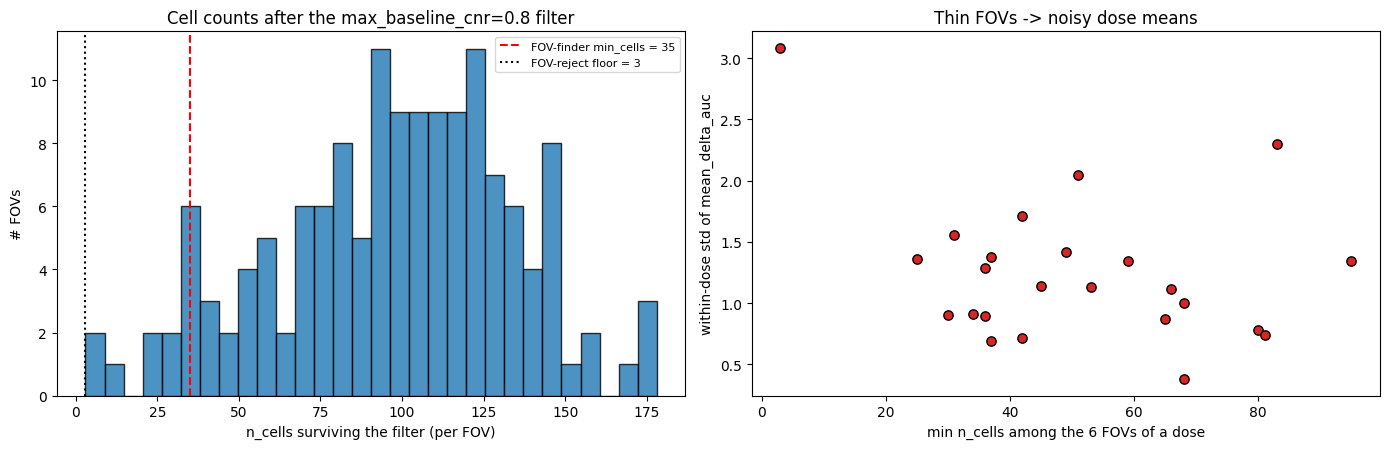

FOVs below the FOV-finder min (35 cells): 8/144
FOVs with < 10 surviving cells:           3/144

Worst-hit dose = 1000 ms -- its 6 FOVs:
 phase_id  n_cells  baseline_cnr  mean_delta_auc
        1      3.0      1.165058        0.761780
        1      7.0      1.154750        1.544530
        1      9.0      1.023847        3.285563
        1     25.0      0.650717        6.796389
        1     73.0      0.632871        7.220875
        1    137.0      0.682207        7.771822

-> within-dose std there = 3.08 AUC, vs the median across all doses of 1.14 AUC.


In [8]:
nc = df_full["n_cells"].to_numpy(float)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

ax = axes[0]
ax.hist(nc, bins=30, color="tab:blue", alpha=0.8, edgecolor="k")
ax.axvline(35, color="r", ls="--", lw=1.5, label="FOV-finder min_cells = 35")
ax.axvline(3, color="k", ls=":", lw=1.5, label="FOV-reject floor = 3")
ax.set_xlabel("n_cells surviving the filter (per FOV)")
ax.set_ylabel("# FOVs")
ax.set_title("Cell counts after the max_baseline_cnr=0.8 filter")
ax.legend(fontsize=8)

# Per-dose: replicate scatter vs how thin the FOVs are.
ax = axes[1]
g = df.assign(n_cells=df_full["n_cells"].values).groupby(P1)
ax.scatter(g["n_cells"].min(), g[OBJ].std(), s=45, c="tab:red", edgecolors="k")
ax.set_xlabel("min n_cells among the 6 FOVs of a dose")
ax.set_ylabel(f"within-dose std of {OBJ}")
ax.set_title("Thin FOVs -> noisy dose means")
plt.tight_layout()
plt.show()

thin = df_full[df_full["n_cells"] < 35]
verythin = df_full[df_full["n_cells"] < 10]
print(f"FOVs below the FOV-finder min (35 cells): {len(thin)}/{len(df_full)}")
print(f"FOVs with < 10 surviving cells:           {len(verythin)}/{len(df_full)}")
print()
worst = df.assign(n_cells=df_full["n_cells"].values)
worst = worst[worst[P1] == worst.loc[worst["n_cells"].idxmin(), P1]]
print(f"Worst-hit dose = {worst[P1].iloc[0]:.0f} ms -- its 6 FOVs:")
print(
    worst[["phase_id", "n_cells", "baseline_cnr", OBJ]]
    .sort_values("n_cells")
    .to_string(index=False)
)
print(
    f"\n-> within-dose std there = {worst[OBJ].std():.2f} AUC, "
    f"vs the median across all doses of "
    f"{df.groupby(P1)[OBJ].std().median():.2f} AUC."
)

### Reading section E

- A handful of FOVs come out of the 0.8 filter with **single-digit cell
  counts** — far below even the FOV-finder's own `min_cells = 35`.  Their
  per-FOV ΔAUC is an average over 3–9 cells: pure sampling noise dressed
  up as a measurement.
- The worst-hit dose has by far the largest within-dose scatter, and it
  is dragged there by its thinnest FOVs.  That one bad dose feeds the GP
  a high-variance point right in the mid-range, blunting the very
  precision v3 was trying to buy.
- The fix is cheap: **add a cell-count floor** (reject an FOV unless,
  say, ≥ 20 cells survive the filter, not 3), or apply the baseline
  filter at the *FOV* level so a whole bad FOV is dropped rather than
  silently reduced to a 3-cell average.  Tightening a filter without a
  floor on what it removes is the bug.

## F — Things I am unhappy about

Each bullet is a real defect of *this run* — biology, statistics, or BO
design.  Next-run diffs are in Section H.

### F1. The whole premise — "commit to Hill" — was unsupported

v3's "Change 1" dropped model selection and committed to Hill *because
v2 reported "saturating with K ≈ 1000 ms"*.  But v2's own data (cell
below) also climbs monotonically to the 5000 ms boundary — its
highest-response dose is 5000 ms too.  v2's saturation claim was an
artefact of fitting a saturating function to a non-saturating curve: the
Hill fit caught the steep early rise and *invented* a plateau the data
never showed.  v3 inherited that error and removed the one mechanism
(multi-candidate model selection) that could have caught it.

### F2. A Hill `K` cannot be measured without observing the plateau

This is pharmacology 101.  `K` (EC50) is the dose at half-maximal
response; it is identified by the *ratio* of a measured response to a
measured maximum.  With no plateau in 25–5000 ms, `K` and `V_max` trade
off along a ridge — exactly the behaviour Section B shows (`K` sliding
1000→4600 ms while `V_max` sinks below the data).  No amount of extra
FOVs at doses ≤ 5000 ms fixes this; you need higher doses or a different
model.

### F3. AUC of `cnr − baseline` is not bounded — but `frac` is, and v3 keeps both

The primary task `mean_delta_auc` is fine as an unbounded continuous
objective.  But the secondary task `frac_peak_responders` is a fraction
in [0, 1] and at the top doses it is already at ~0.9 — the same
ceiling-saturation pathology the v11 pitch flagged (F3 there).  It
contributes at weight 0.3 to the joint acquisition, so it is quietly
pulling the sampler with a saturating signal.

### F4. `optortk_expression` is marginalised when it should be modelled

Section D: it explains ~30 % of the dose-fit residual variance.
Marginalising a covariate that strong is throwing away signal and
inflating every predictive interval in the notebook.  It belongs on the
GP input axis as a *modelled* effect — and ideally per-cell, not an FOV
mean (the FOV mean smears a 2× cell-to-cell expression spread into one
number).

### F5. The tighter baseline filter has no floor

Section E: tightening `max_baseline_cnr` to 0.8 with an FOV-reject
threshold of only 3 surviving cells produced several 3–9-cell FOVs whose
means are noise.  A good filter change comes with a floor on what it is
allowed to remove.

### F6. `baseline_cnr` is both a filter criterion and a regressor

The per-cell filter conditions on baseline CNR; `baseline_cnr` is then
also fed to the GP as a covariate.  Conditioning on a variable at
selection time and regressing on it afterwards is collider
stratification — its coefficient is not interpretable.  (Same defect as
the v11 pitch F6.)

### F7. No stopping rule, and the run is short anyway

The notebook ships with "no formal stopping rule — stop when the K
posterior tightens".  The K posterior never tightened (Section B), so
there was no signal to stop on.  The run also did **8 phases**, while the
notebook's own configure-cell markdown says 10 — a config/markdown
mismatch worth fixing for reproducibility.

### F8. Single stim frame ⇒ dose = duration only

v3 varies `pulse_duration` at fixed power (10) and a single stim frame.
"Dose" here is one knob.  optoRTK biology has at least two (irradiance ×
duration, plus pulse number).  A genuinely flat dose-response ceiling
might be a receptor-occupancy limit that more duration cannot exceed —
in which case the "no saturation in 25–5000 ms" result of Section C is
itself the interesting finding, and the experiment should pivot to
*power* as the next axis.

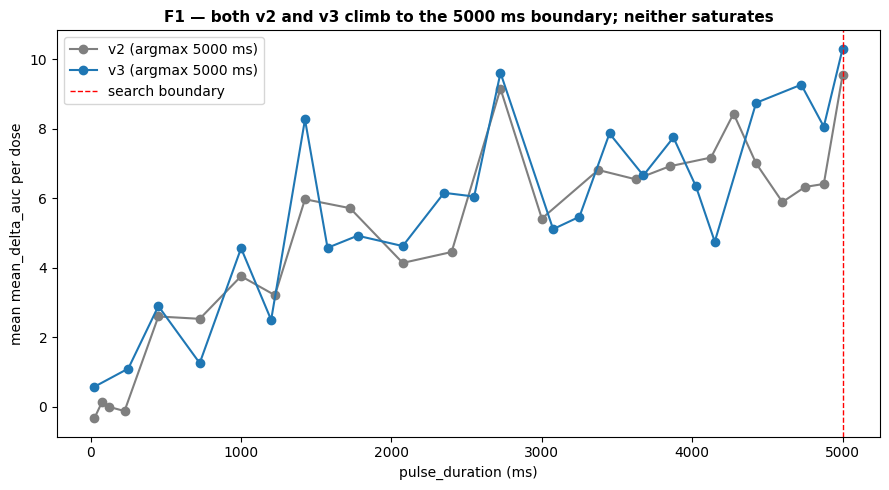

v2: highest-response dose = 5000 ms  (this is the run that reported 'saturating, K ~ 1000 ms')
v3: highest-response dose = 5000 ms
Both argmaxes sit on the search boundary -> the saturation premise was never in the data.


In [9]:
# F1 evidence: v2's data also climbs to the boundary.
df_v2 = load_phased(V2_PATH)
agg_v2 = df_v2.groupby(P1)[OBJ].mean()
agg_v3 = df.groupby(P1)[OBJ].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    agg_v2.index,
    agg_v2.values,
    "o-",
    color="tab:gray",
    label=f"v2 (argmax {agg_v2.idxmax():.0f} ms)",
)
ax.plot(
    agg_v3.index,
    agg_v3.values,
    "o-",
    color="tab:blue",
    label=f"v3 (argmax {agg_v3.idxmax():.0f} ms)",
)
ax.axvline(PULSE_MAX_MS, color="r", ls="--", lw=1, label="search boundary")
ax.set_xlabel("pulse_duration (ms)")
ax.set_ylabel(f"mean {OBJ} per dose")
ax.set_title(
    "F1 — both v2 and v3 climb to the 5000 ms boundary; " "neither saturates",
    fontsize=11,
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"v2: highest-response dose = {agg_v2.idxmax():.0f} ms  "
    f"(this is the run that reported 'saturating, K ~ 1000 ms')"
)
print(f"v3: highest-response dose = {agg_v3.idxmax():.0f} ms")
print(
    "Both argmaxes sit on the search boundary -> the saturation premise "
    "was never in the data."
)

## G — The slide-ready pitch (what I would and would *not* claim)

### What v3 honestly delivered

**1. A clean falsification.**  *(strongest claim)*  The ERK single-pulse
dose-response **does not saturate within 25–5000 ms** — it rises roughly
with `log(dose)` all the way to the 5 s boundary (Section C, model-free
GP + log-linear fit, R² ≈ 0.5).  This overturns v2's "saturating,
EC50 ≈ 1 s" conclusion.  A negative result that corrects the record is a
result.

**2. A calibrated model-free dose-response map.**  Section C gives a
posterior dose-response over the full range with covariate-marginalised
uncertainty — usable to *design the next experiment* even though it is
not a Hill fit.

**3. A covariate finding.**  `optortk_expression` explains ~30 % of the
non-dose variance (Section D).  Expression level is a first-class driver
of ERK response amplitude — worth a panel on its own, and it tells the
next run to control or model expression explicitly.

**4. The BO machinery worked.**  MaxVar covered the dose axis as
intended (Section A); the cross-phase repulsion and checkpointing did
their jobs.  The failure was upstream of the optimiser.

### What I would NOT claim

- ❌ **"v3 measured the EC50."**  It did not.  `K` never converged and
  its CI runs past the search boundary (Section B).  There is no EC50 to
  report — the half-max dose is at or beyond 5 s.
- ❌ **"The dose-response is cooperative (Hill n ≈ 2.5)."**  `n` is a
  by-product of an unidentified fit; it carries no evidence.
- ❌ **"Hill is the right model."**  v2 showed Hill ≈ exp on this readout;
  v3 showed the data is non-saturating, so *neither* saturating family is
  right within range.  A log-linear / power-law description is the honest
  one until higher doses are measured.
- ❌ **"v3 was a wasted plate."**  144 FOVs bought a firm falsification, a
  covariate result, and a clear next-experiment design.  That is a
  productive negative run — but call it that, not a parameter-inference
  success.

## H — Concrete diffs for the next run

Ranked by payoff per unit effort.

### Tier 1 — fix the premise (do before the next plate)

1. **Decide what you are measuring.**  Either (a) **extend the dose
   range** upward — add a second stim frame or raise power so the curve
   can reach a plateau, *then* a Hill `K` is identifiable; or (b) accept
   the curve is non-saturating in the deliverable range and **switch the
   mean function to log-linear / power-law**, reporting a slope, not an
   EC50.  Pick one before running, not after.
2. **Put model selection back.**  v3's "Hill only" removed the safety
   valve.  Restore a candidate set that includes a non-saturating family
   (`power_law`, `linear-in-log`) so the agent can *tell you* the data
   isn't saturating instead of silently mis-fitting Hill.
3. **Add a cell-count floor to the baseline filter.**  Reject an FOV
   unless ≥ ~20 cells survive `max_baseline_cnr`, or apply the filter at
   FOV level.  Kills the 3–9-cell noise FOVs (Section E).

### Tier 2 — fix the model (before the next BO design)

4. **Promote `optortk_expression` from marginalised covariate to a
   modelled GP axis** — ideally per-cell expression, not the FOV mean.
   Section D says it carries ~30 % of the residual; modelling it will
   tighten every prediction and de-confound the dose-response.
5. **Drop `baseline_cnr` as a GP covariate** (it is the filter criterion
   — collider, F6), or screen on a different criterion than you regress
   on.
6. **Reconsider the secondary `frac_peak_responders` task.**  It
   saturates at the top doses (F3); either logit-transform consistently
   or drop it from the joint acquisition so it stops pulling the sampler
   with a ceilinged signal.

### Tier 3 — worth doing once

7. **Real biological replicates.**  Two plates, different days, fresh
   transfection; pool with a plate-level random effect so the
   dose-response CI is across-plate, not within-plate.
8. **Make `pulse_power` (irradiance) a second BO axis.**  If duration
   alone cannot saturate the response, the ceiling may be a power-limited
   receptor-occupancy effect.  A 2-D `(duration, power)` dose-response is
   the natural next experiment — and `auc_per_light` (v12-style) is the
   right efficiency objective for it.

### Tier 4 — clean-up

9. **Reconcile `N_PHASES`.**  The config cell sets 8, the markdown says
   10 (F7).  Fix one.
10. **Add the stopping rule the notebook promises** — but key it to a
    quantity that *can* converge (e.g. the model-free GP's predicted
    response at a fixed reference dose), not to a Hill `K` that may never
    settle.